# IRI historical

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [77]:
import os
from pathlib import Path

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ochanticipy import (
    create_country_config,
    CodAB,
    GeoBoundingBox,
    IriForecastProb,
)

In [162]:
DATA_DIR = Path(os.getenv("AA_DATA_DIR"))
SAH_IRI_PATH = (
    DATA_DIR
    / "private"
    / "processed"
    / "sah"
    / "iri"
    / "sah_iri_forecast_seasonal_precipitation_tercile_prob_Np24Sp7Ep24Wm6.nc"
)
BFA_PROC_DIR = DATA_DIR / "private" / "processed" / "bfa" / "iri"

In [47]:
def upsample_dataarray(
    da: xr.DataArray, resolution: float = 0.1
) -> xr.DataArray:
    new_lat = np.arange(da.latitude.min(), da.latitude.max(), resolution)
    new_lon = np.arange(da.longitude.min(), da.longitude.max(), resolution)
    return da.interp(latitude=new_lat, longitude=new_lon, method="nearest")

In [25]:
adm1_sel = ["Boucle du Mouhoun", "Nord", "Centre-Nord", "Sahel"]

country_config = create_country_config(iso3="bfa")
codab = CodAB(country_config=country_config)
# codab.download()
gdf_adm1 = codab.load(admin_level=1)
geobb = GeoBoundingBox.from_shape(gdf_adm1)
gdf_aoi = gdf_adm1.loc[gdf_adm1.ADM1_FR.isin(adm1_sel)]

In [44]:
iri = xr.load_dataset(SAH_IRI_PATH)
iri = iri.rename({"X": "longitude", "Y": "latitude"})
iri = iri.rio.write_crs(4326)
iri_up = upsample_dataarray(iri, resolution=0.05)
iri_up_clip = iri_up.rio.clip(gdf_aoi.geometry, all_touched=True)

<Axes: title={'center': 'L = 1.0 [months], F = 2017-02-16 00:00:00, spat...'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

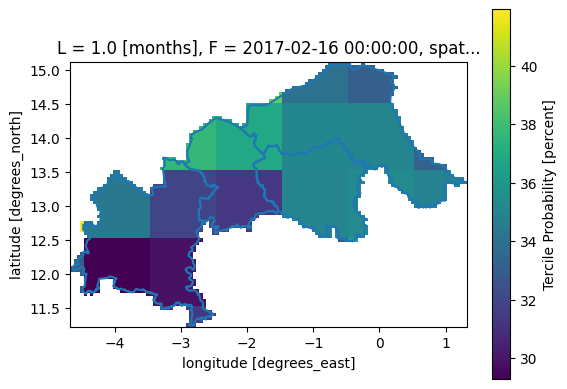

In [45]:
fig, ax = plt.subplots()
iri_up_clip.isel(F=0, L=0, C=0)["prob"].plot(ax=ax)
gdf_aoi.boundary.plot(ax=ax)

In [100]:
df = iri_up_clip.to_dataframe()["prob"].dropna().reset_index()
df["F"] = pd.to_datetime(df["F"].apply(lambda x: x.strftime("%Y-%m-%d")))

In [101]:
df["year"] = df["F"].dt.year
df["f_month"] = df["F"].dt.month
df["C"] = df["C"].replace({0: "lower", 1: "average", 2: "higher"})
df = df.pivot(
    columns="C",
    values="prob",
    index=["L", "year", "f_month", "latitude", "longitude"],
).reset_index()
df

C,L,year,f_month,latitude,longitude,average,higher,lower
0,1.0,2017,2,11.25,-2.90,30.684258,37.971257,31.344484
1,1.0,2017,2,11.25,-2.85,30.684258,37.971257,31.344484
2,1.0,2017,2,11.25,-2.80,30.684258,37.971257,31.344484
3,1.0,2017,2,11.30,-2.85,30.684258,37.971257,31.344484
4,1.0,2017,2,11.30,-2.80,30.684258,37.971257,31.344484
...,...,...,...,...,...,...,...,...
1048355,4.0,2023,10,15.10,-0.60,33.672096,34.145778,32.182126
1048356,4.0,2023,10,15.10,-0.55,33.672096,34.145778,32.182126
1048357,4.0,2023,10,15.10,-0.50,33.672096,34.145778,32.182126
1048358,4.0,2023,10,15.10,-0.45,33.500061,31.394568,35.105371


In [103]:
df["high_low_diff"] = df["lower"] - df["higher"]

In [160]:
area_frac = 0.1

dicts = []

for year in df["year"].unique():
    df_year = df[df["year"] == year]
    # March forecast for JJA
    dff = df_year[(df_year["f_month"] == 3) & (df_year["L"] == 3)]
    march_lower, march_diff = dff.quantile(1 - area_frac)[
        ["lower", "high_low_diff"]
    ]
    # July forecast for ASO
    dff = df_year[(df_year["f_month"] == 7) & (df_year["L"] == 1)]
    july_lower, july_diff = dff.quantile(1 - area_frac)[
        ["lower", "high_low_diff"]
    ]
    dicts.append(
        {
            "year": year,
            "march_lower": march_lower,
            "march_diff": march_diff,
            "july_lower": july_lower,
            "july_diff": july_diff,
        }
    )

results = pd.DataFrame(dicts)
results["march_act"] = (results["march_lower"] > 40) & (
    results["march_diff"] > 5
)
results["july_act"] = (results["july_lower"] > 40) & (results["july_diff"] > 5)
results["either_act"] = results["march_act"] | results["july_act"]

In [164]:
results
filename = "historical_forecast_activations.csv"
results.to_csv(BFA_PROC_DIR / filename, index=False)